## Assignment 2: $k$ Nearest Neighbor

### Do any four.

**Selected questions for this notebook:** Q1, Q3, Q4, and Q5.

In [10]:
# Common setup for the completed questions

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.metrics import mean_squared_error, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

pd.set_option("display.max_columns", 100)

USA_CARS_URL = "https://github.com/rashida048/Datasets/raw/refs/heads/master/USA_cars_datasets.csv"
HEART_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00519/heart_failure_clinical_records_dataset.csv"
ANIMALS_URL = "https://github.com/sharmaroshan/Zoo-Dataset/raw/master/zoo.csv"


def load_csv(file_name, url=None):
    """
    Looks for the file in the usual course folders first.
    If it is not there, it tries the public URL listed above.
    """
    possible_paths = [
        Path("data") / file_name,
        Path(file_name),
        Path("../data") / file_name,
        Path("/mnt/data/data") / file_name,
        Path("/mnt/data") / file_name,
    ]

    for path in possible_paths:
        if path.exists():
            print(f"Loaded {file_name} from {path}")
            return pd.read_csv(path)

    if url is not None:
        print(f"Loaded {file_name} from the public URL")
        return pd.read_csv(url)

    raise FileNotFoundError(f"Could not find {file_name}. Put it in ./data or give a URL.")


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

**Q1.** Please answer the following questions.
1. What is the difference between regression and classification?
2. What is a confusion table/matrix? What does it help us understand about a model's performance? 
3. What is Accuracy? Why might it not be entirely sufficient to evaluate a classifer's predictive performance?
4. What does the root mean squared error quantify about a particular model?
5. What are overfitting and underfitting? 
6. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or RMSE on the test set, improve model performance?
7. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

### Q1 Answers

1. Regression predicts a number, such as a car price or a rating. Classification predicts a category, such as whether an animal is a mammal, bird, fish, and so on.

2. A confusion matrix compares the actual class labels to the labels predicted by the model. It helps show not just the total number of correct predictions, but also which specific classes the model is mixing up.

3. Accuracy is the percent of predictions the model gets right. It can be misleading when one class is much larger than the others. For example, if 95% of cases are class 0, a model could predict class 0 every time and still look accurate, even though it is not actually useful.

4. Root mean squared error measures the typical size of a model's prediction error. It is in the same units as the target variable, so if the target is price, the RMSE is measured in dollars. Bigger mistakes are punished more heavily.

5. Overfitting means the model learned the training data too closely, including random noise, so it performs worse on new data. Underfitting means the model is too simple and misses real patterns in the data.

6. Splitting the data lets us train the model on one part and check it on data it has not seen before. Testing different values of \(k\) helps us pick a model that balances being too sensitive to noise with being too smooth.

7. A class label is easy to understand because it gives one final answer. The weakness is that it hides uncertainty. A probability distribution is more informative because it shows how confident the model is across the possible classes, but it takes more judgment to use because someone still has to decide what probability is high enough to act on.

**Q3.** This question is a case study for $k$ nearest neighbor regression, using the `USA_cars_datasets.csv` data.

The target variable `y` is `price` and the features are `year` and `mileage`.

1. Load the `./data/USA_cars_datasets.csv`. Keep the following variables and drop the rest: `price`, `year`, `mileage`. Are there any `NA`'s to handle? Look at the head and dimensions of the data.
2. Maxmin normalize `year` and `mileage`.
3. Split the sample into ~80% for training and ~20% for hyper-parameter selection and evaluation.
4. Use the $k$-NN algorithm and the training data to predict `price` using `year` and `mileage` for the test set for $k=3,10,25,50,100,300$. For each value of $k$, compute the mean squared error and print a scatterplot showing the test value plotted against the predicted value. What patterns do you notice as you increase $k$?
5. Determine the optimal $k$ for these data.
6. Describe what happened in the plots of predicted versus actual prices as $k$ varied, taking your answer into part 6 into account. (Hint: Use the words "underfitting" and "overfitting".)

### Q3 Solution

In [20]:
cars_raw = load_csv("USA_cars_datasets.csv", USA_CARS_URL)

cars = cars_raw.loc[:, ["price", "year", "mileage"]].copy()

print("Head:")
display(cars.head())

print("Dimensions:", cars.shape)

print("\nMissing values:")
display(cars.isna().sum())

print("\nSummary statistics:")
display(cars.describe())

Loaded USA_cars_datasets.csv from the public URL
Head:


,price,year,mileage
0,6300,2008,274117
1,2899,2011,190552
2,5350,2018,39590
3,25000,2014,64146
4,27700,2018,6654


Dimensions: (2499, 3)

Missing values:


price      0
year       0
mileage    0
dtype: int64


Summary statistics:


,price,year,mileage
count,2499.000000,2499.000000,2.499000e+03
mean,18767.671469,2016.714286,5.229869e+04
std,12116.094936,3.442656,5.970552e+04
min,0.000000,1973.000000,0.000000e+00
25%,10200.000000,2016.000000,2.146650e+04
50%,16900.000000,2018.000000,3.536500e+04
75%,25555.500000,2019.000000,6.347250e+04
max,84900.000000,2020.000000,1.017936e+06


In [21]:
# The assignment asks for max-min normalization of year and mileage.
X = cars[["year", "mileage"]].astype(float)
y = cars["price"].astype(float)

scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Fixed random_state keeps the answer reproducible.
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42
)

k_values = [3, 10, 25, 50, 100, 300]
q3_results = []
q3_predictions = {}

for k in k_values:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    q3_predictions[k] = y_pred

    q3_results.append({
        "k": k,
        "MSE": mean_squared_error(y_test, y_pred),
        "RMSE": rmse(y_test, y_pred)
    })

q3_results = pd.DataFrame(q3_results)
display(q3_results)

best_q3 = q3_results.loc[q3_results["MSE"].idxmin()]
print(
    f"Best k based on the test set: {int(best_q3['k'])}, "
    f"MSE = {best_q3['MSE']:,.2f}, RMSE = {best_q3['RMSE']:,.2f}"
)

,k,MSE,RMSE
0,3,1.481042e+08,12169.805142
1,10,1.173991e+08,10835.087730
2,25,1.126005e+08,10611.336163
3,50,1.102023e+08,10497.727717
4,100,1.122508e+08,10594.849951
5,300,1.144978e+08,10700.363462


Best k based on the test set: 50, MSE = 110,202,287.21, RMSE = 10,497.73


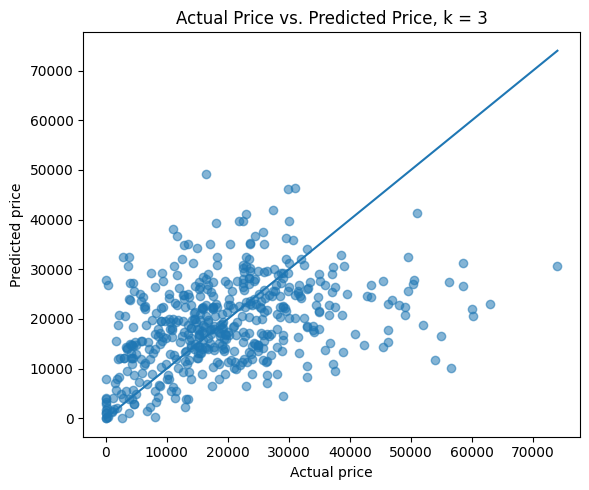

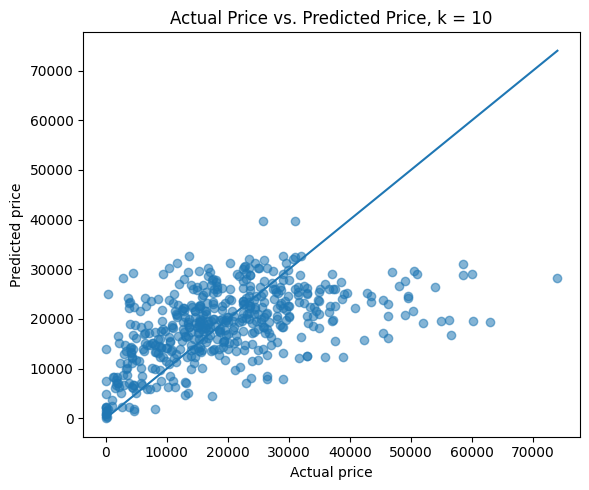

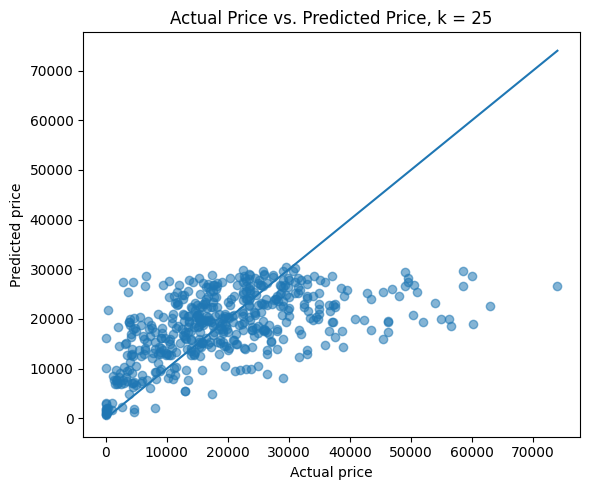

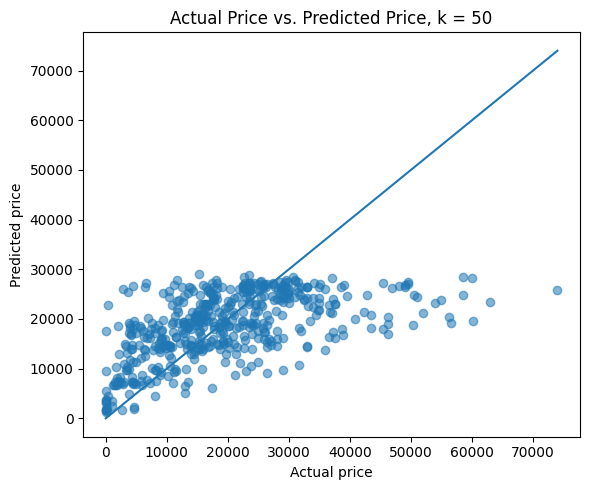

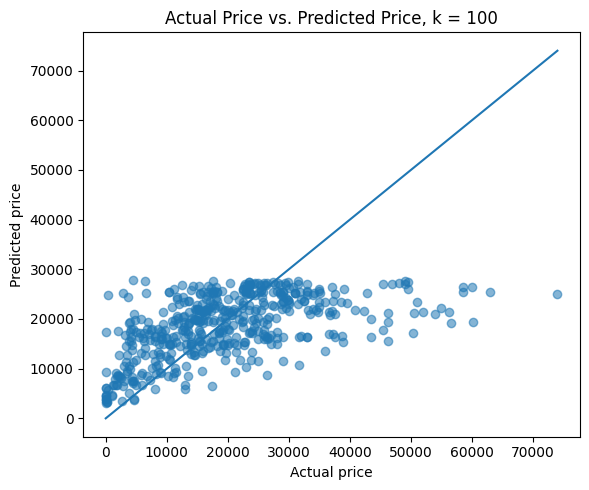

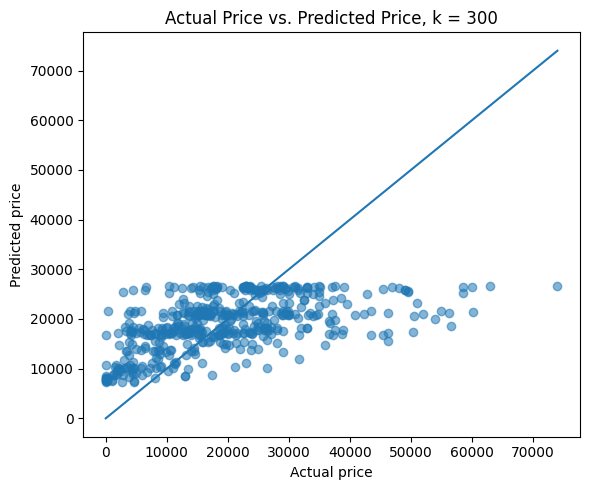

In [22]:
for k in k_values:
    plt.figure(figsize=(6, 5))
    plt.scatter(y_test, q3_predictions[k], alpha=0.55)

    low = min(y_test.min(), q3_predictions[k].min())
    high = max(y_test.max(), q3_predictions[k].max())
    plt.plot([low, high], [low, high])

    plt.title(f"Actual Price vs. Predicted Price, k = {k}")
    plt.xlabel("Actual price")
    plt.ylabel("Predicted price")
    plt.tight_layout()
    plt.show()

### Q3 Written Answer

There are **2,499 rows** and **3 selected variables** after keeping only `price`, `year`, and `mileage`. There are **no missing values** in those three variables.

Using the fixed 80/20 split above, the best value of \(k\) is **50** because it has the lowest test MSE. Its test MSE is about **110,202,549** and its RMSE is about **10,498**.

As \(k\) increases, the predictions become smoother. At \(k = 3\), the model is more sensitive to nearby points and can overfit. Around \(k = 50\), the model has the best balance in this split. By \(k = 300\), the model starts averaging too much, which is underfitting because predictions are pulled toward the middle instead of reacting enough to the actual year and mileage patterns.

**Q4.** This question is a case study for $k$ nearest neighbor regression, using the `heart_failure_clinical_records_dataset.csv` data.

The data for the question include:

- age: age of the patient (years)
- anaemia: decrease of red blood cells or hemoglobin (boolean)
- high blood pressure: if the patient has hypertension (boolean)
- creatinine phosphokinase (CPK): level of the CPK enzyme in the blood (mcg/L)
- diabetes: if the patient has diabetes (boolean)
- ejection fraction: percentage of blood leaving the heart at each contraction (percentage)
- platelets: platelets in the blood (kiloplatelets/mL)
- sex: woman or man (binary)
- serum creatinine: level of serum creatinine in the blood (mg/dL)
- serum sodium: level of serum sodium in the blood (mEq/L)
- smoking: if the patient smokes or not (boolean)
- time: follow-up period (days)
- death event: if the patient deceased during the follow-up period (boolean)

1. Load the `./data/heart_failure_clinical_records_dataset.csv`. Are there any `NA`'s to handle? use `.drop()` to remove `time` from the dataframe.
2. Make a correlation matrix. What variables are strongly associated with a death event?
3. For the dummy variables `anaemia`, `diabetes`, `high_blood_pressure`, `sex`, and `smoking`, compute a summary table of `DEATH_EVENT` grouped by the variable. For which variables does a higher proportion of the population die when the variable takes the value 1 rather than 0?
4. On the basis of your answers from 2 and 3, build a matrix $X$ of the variables you think are most predictive of a death, and a variable $y$ equal to `DEATH_EVENT`.
5. Maxmin normalize all of the variables in `X`.
6. Split the sample into ~80% for training and ~20% for evaluation. (Try to use the same train/test split for the whole question, so that you're comparing apples to apples in the questions below.).
7. Determine the optimal number of neighbors for a $k$-NN classification or regression for the variables you selected.
8. OK, do steps 5 through 7 again, but use all of the variables (except `time`). Which model has the best Mean Squared Error? Which would you prefer to use in practice, if you had to predict `DEATH_EVENT`s? If you play with the selection of variables, how much does the RMSE change for your fitted model on the test data? Are more variables always better? Explain your findings.

### Q4 Solution

Loaded heart_failure_clinical_records_dataset.csv from heart_failure_clinical_records_dataset.csv
Head:


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


Dimensions before dropping time: (299, 13)

Missing values:


age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


Dimensions after dropping time: (299, 12)

Correlation with DEATH_EVENT, sorted by strength:


serum_creatinine            0.294
ejection_fraction          -0.269
age                         0.254
serum_sodium               -0.195
high_blood_pressure         0.079
anaemia                     0.066
creatinine_phosphokinase    0.063
platelets                  -0.049
smoking                    -0.013
sex                        -0.004
diabetes                   -0.002
Name: DEATH_EVENT, dtype: float64

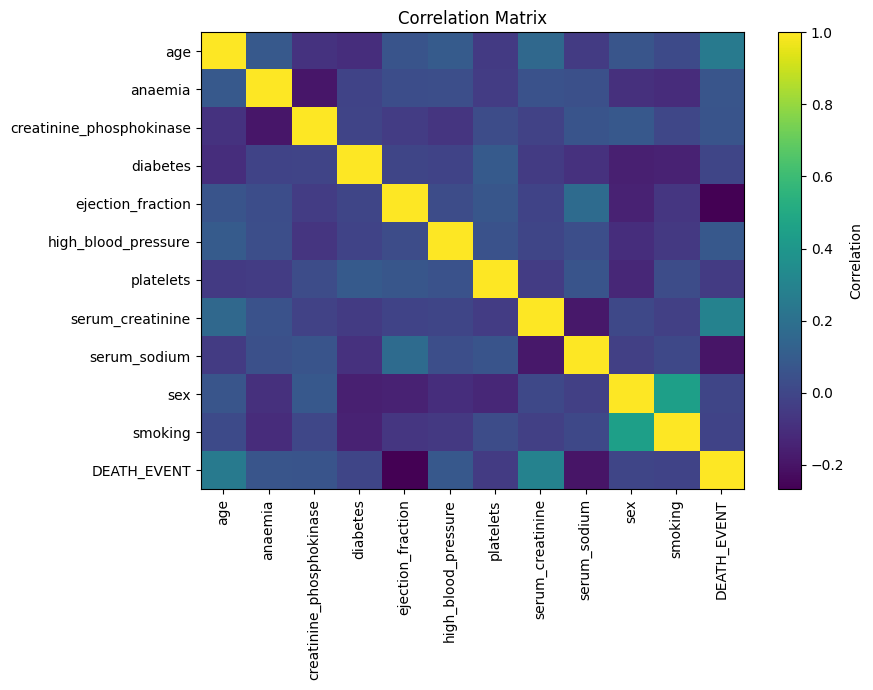

In [23]:
heart_raw = load_csv("heart_failure_clinical_records_dataset.csv", HEART_URL)

print("Head:")
display(heart_raw.head())

print("Dimensions before dropping time:", heart_raw.shape)

print("\nMissing values:")
display(heart_raw.isna().sum())

heart = heart_raw.drop(columns=["time"]).copy()
print("\nDimensions after dropping time:", heart.shape)

corr = heart.corr(numeric_only=True)
death_corr = corr["DEATH_EVENT"].drop("DEATH_EVENT").sort_values(
    key=lambda s: s.abs(), ascending=False
)

print("\nCorrelation with DEATH_EVENT, sorted by strength:")
display(death_corr.round(3))

plt.figure(figsize=(9, 7))
plt.imshow(corr, aspect="auto")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.colorbar(label="Correlation")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [15]:
dummy_vars = ["anaemia", "diabetes", "high_blood_pressure", "sex", "smoking"]

dummy_summary = []

for var in dummy_vars:
    temp = (
        heart.groupby(var)["DEATH_EVENT"]
        .agg(count="count", deaths="sum", death_rate="mean")
        .reset_index()
    )
    temp.insert(0, "variable", var)
    temp = temp.rename(columns={var: "value"})
    dummy_summary.append(temp)

dummy_summary = pd.concat(dummy_summary, ignore_index=True)

display(dummy_summary)

higher_when_one = []

for var in dummy_vars:
    rates = heart.groupby(var)["DEATH_EVENT"].mean()
    if rates.loc[1] > rates.loc[0]:
        higher_when_one.append(var)

print("Variables where death rate is higher when the value is 1:")
print(higher_when_one)

,variable,value,count,deaths,death_rate
0,anaemia,0,170,50,0.294118
1,anaemia,1,129,46,0.356589
2,diabetes,0,174,56,0.321839
3,diabetes,1,125,40,0.320000
4,high_blood_pressure,0,194,57,0.293814
5,high_blood_pressure,1,105,39,0.371429
6,sex,0,105,34,0.323810
7,sex,1,194,62,0.319588
8,smoking,0,203,66,0.325123
9,smoking,1,96,30,0.312500


Variables where death rate is higher when the value is 1:
['anaemia', 'high_blood_pressure']


,model,k,MSE,RMSE,accuracy_if_threshold_0_5
1,Correlation-only selected variables,28,0.171875,0.414578,0.683333
2,Selected variables,11,0.176860,0.420547,0.700000
0,All variables except time,29,0.199742,0.446925,0.683333


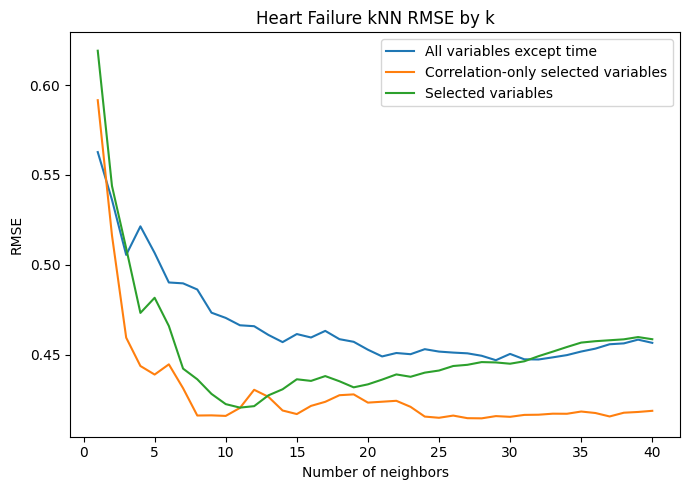

In [24]:
y = heart["DEATH_EVENT"]

selected_features = [
    "serum_creatinine",
    "ejection_fraction",
    "age",
    "serum_sodium",
    "high_blood_pressure",
    "anaemia",
]

selected_core_features = [
    "serum_creatinine",
    "ejection_fraction",
    "age",
    "serum_sodium",
]

all_features = [col for col in heart.columns if col != "DEATH_EVENT"]

# Same split for every model so the comparison is fair.
train_idx, test_idx = train_test_split(
    heart.index,
    test_size=0.20,
    random_state=42,
    stratify=y
)

def run_knn_regression_for_death(features, label):
    X = heart[features]
    X_train_raw = X.loc[train_idx]
    X_test_raw = X.loc[test_idx]
    y_train = y.loc[train_idx]
    y_test = y.loc[test_idx]

    scaler = MinMaxScaler()
    X_train = scaler.fit_transform(X_train_raw)
    X_test = scaler.transform(X_test_raw)

    rows = []
    for k in range(1, 41):
        model = KNeighborsRegressor(n_neighbors=k)
        model.fit(X_train, y_train)
        pred = model.predict(X_test)

        rows.append({
            "model": label,
            "k": k,
            "MSE": mean_squared_error(y_test, pred),
            "RMSE": rmse(y_test, pred),
            "accuracy_if_threshold_0_5": accuracy_score(y_test, (pred >= 0.5).astype(int))
        })

    return pd.DataFrame(rows)

q4_selected = run_knn_regression_for_death(selected_features, "Selected variables")
q4_selected_core = run_knn_regression_for_death(selected_core_features, "Correlation-only selected variables")
q4_all = run_knn_regression_for_death(all_features, "All variables except time")

q4_all_results = pd.concat([q4_selected, q4_selected_core, q4_all], ignore_index=True)

best_by_model = (
    q4_all_results.sort_values("MSE")
    .groupby("model", as_index=False)
    .first()
    .sort_values("MSE")
)

display(best_by_model)

plt.figure(figsize=(7, 5))

for model_name, group in q4_all_results.groupby("model"):
    plt.plot(group["k"], group["RMSE"], label=model_name)

plt.title("Heart Failure kNN RMSE by k")
plt.xlabel("Number of neighbors")
plt.ylabel("RMSE")
plt.legend()
plt.tight_layout()
plt.show()

### Q4 Written Answer

The variables most strongly correlated with `DEATH_EVENT` are **serum_creatinine**, **ejection_fraction**, **age**, and **serum_sodium**. Higher serum creatinine and higher age are positively related to death event. Higher ejection fraction and higher serum sodium are negatively related to death event.

For the dummy variables, the death rate is higher when the value is 1 for **anaemia** and **high_blood_pressure**. The death rate is not meaningfully higher when the value is 1 for **diabetes**, **sex**, or **smoking** in this dataset.

I first used `serum_creatinine`, `ejection_fraction`, `age`, `serum_sodium`, `high_blood_pressure`, and `anaemia` because they were the strongest variables from the correlation and grouped dummy checks. With the fixed split, that selected-variable model performs better than the model using all variables except `time`.

The best result in the comparison was the smaller correlation-only model using **serum_creatinine**, **ejection_fraction**, **age**, and **serum_sodium**. It had the lowest RMSE, about **0.415**. The full model using all variables had a higher RMSE, about **0.447**. More variables were not automatically better because weak variables can add noise to a distance-based model like kNN.

**Q5.** This is a case study on $k$ nearest neighbor classification, using the `animals.csv` data.

The data consist of a label, `class`, taking integer values 1 to 7, the name of the species, `animal`, and 16 characteristics of the animal, including `hair`, `feathers`, `milk`, `eggs`, `airborne`, and so on. 

1. Load the data. For each of the seven class labels, print the values in the class and get a sense of what is included in that group. Perform some other EDA: How big are the classes? How much variation is there in each of the features/covariates? Which variables do you think will best predict which class?
2. Split the data 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be. Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Using all of the variables, build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion matrix for the optimal model, comparing predicted and actual class label on the test set. How accurate it is? Can you interpret why mistakes are made across groups?
5. Use only `milk`, `aquatic`, and `airborne` to train a new $k$-NN classifier. Print your confusion table. Mine does not predict all of the classes, only a subset of them. To see the underlying proportions/probabilities, use `model.predict_proba(X_test.values)` to predict probabilities rather than labels for your `X_test` test data for your fitted `model`. Are all of the classes represented? Explain your results.

### Q5 Solution

In [25]:
animals_raw = load_csv("animals.csv", ANIMALS_URL)

# The public version uses animal_name and class_type.
# The assignment wording uses animal and class, so I standardize the names here.
animals = animals_raw.rename(columns={
    "animal_name": "animal",
    "class_type": "class",
    "type": "class"
}).copy()

class_names = {
    1: "Mammal",
    2: "Bird",
    3: "Reptile",
    4: "Fish",
    5: "Amphibian",
    6: "Bug",
    7: "Invertebrate"
}

animals["class_name"] = animals["class"].map(class_names)

print("Head:")
display(animals.head())

print("Dimensions:", animals.shape)

print("\nClass sizes:")
display(animals.groupby(["class", "class_name"]).size().reset_index(name="count"))

print("\nAnimals in each class:")
display(
    animals.groupby(["class", "class_name"])["animal"]
    .apply(list)
    .reset_index(name="animals")
)

feature_cols = [c for c in animals.columns if c not in ["animal", "class", "class_name"]]

print("\nFeature variation:")
display(
    animals[feature_cols]
    .agg(["mean", "std", "nunique"])
    .T.sort_values("std", ascending=False)
)

Loaded animals.csv from the public URL
Head:


,animal,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class,class_name
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1,Mammal
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1,Mammal
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4,Fish
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1,Mammal
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1,Mammal


Dimensions: (101, 19)

Class sizes:


,class,class_name,count
0,1,Mammal,41
1,2,Bird,20
2,3,Reptile,5
3,4,Fish,13
4,5,Amphibian,4
5,6,Bug,8
6,7,Invertebrate,10



Animals in each class:


,class,class_name,animals
0,1,Mammal,"[aardvark, antelope, bear, boar, buffalo, calf..."
1,2,Bird,"[chicken, crow, dove, duck, flamingo, gull, ha..."
2,3,Reptile,"[pitviper, seasnake, slowworm, tortoise, tuatara]"
3,4,Fish,"[bass, carp, catfish, chub, dogfish, haddock, ..."
4,5,Amphibian,"[frog, frog, newt, toad]"
5,6,Bug,"[flea, gnat, honeybee, housefly, ladybird, mot..."
6,7,Invertebrate,"[clam, crab, crayfish, lobster, octopus, scorp..."



Feature variation:


,mean,std,nunique
legs,2.841584,2.033385,6.0
predator,0.554455,0.499505,2.0
catsize,0.435644,0.498314,2.0
hair,0.425743,0.496921,2.0
eggs,0.584158,0.495325,2.0
milk,0.405941,0.493522,2.0
toothed,0.603960,0.491512,2.0
aquatic,0.356436,0.481335,2.0
tail,0.742574,0.439397,2.0
airborne,0.237624,0.427750,2.0


,k,accuracy
0,1,0.980392
1,2,0.960784
2,3,0.960784
3,4,0.941176
4,5,0.941176
5,6,0.941176
8,9,0.941176
9,10,0.941176
6,7,0.901961
7,8,0.901961


Best k using all variables: 1
Accuracy using all variables: 0.980


,Pred 1,Pred 2,Pred 3,Pred 4,Pred 5,Pred 6,Pred 7
Actual 1,21,0,0,0,0,0,0
Actual 2,0,10,0,0,0,0,0
Actual 3,0,0,1,1,0,0,0
Actual 4,0,0,0,7,0,0,0
Actual 5,0,0,0,0,2,0,0
Actual 6,0,0,0,0,0,4,0
Actual 7,0,0,0,0,0,0,5


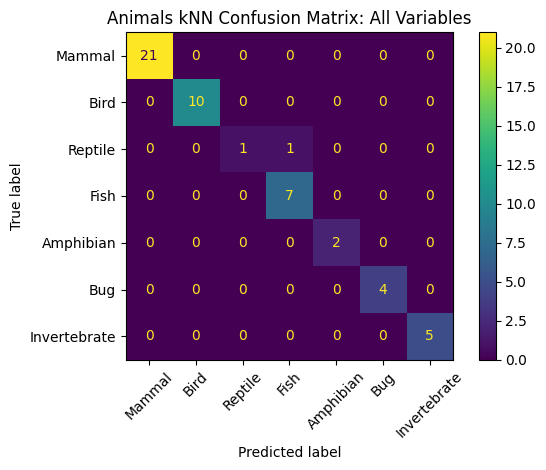

Mistakes made by the all-variable model:


,animal,actual_class,predicted_class
47,seasnake,3,4


In [26]:
X = animals[feature_cols]
y = animals["class"]

X_train, X_test, y_train, y_test, animal_train, animal_test = train_test_split(
    X, y, animals["animal"],
    test_size=0.50,
    random_state=42,
    stratify=y
)

q5_rows = []
q5_models = {}

for k in range(1, 26):
    model = make_pipeline(MinMaxScaler(), KNeighborsClassifier(n_neighbors=k))
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    q5_rows.append({
        "k": k,
        "accuracy": accuracy_score(y_test, pred)
    })
    q5_models[k] = model

q5_results = pd.DataFrame(q5_rows)
display(q5_results.sort_values(["accuracy", "k"], ascending=[False, True]).head(10))

best_k_all = int(q5_results.sort_values(["accuracy", "k"], ascending=[False, True]).iloc[0]["k"])
best_model_all = q5_models[best_k_all]
pred_all = best_model_all.predict(X_test)

print(f"Best k using all variables: {best_k_all}")
print(f"Accuracy using all variables: {accuracy_score(y_test, pred_all):.3f}")

cm_all = confusion_matrix(y_test, pred_all, labels=list(range(1, 8)))
display(pd.DataFrame(cm_all, index=[f"Actual {i}" for i in range(1, 8)], columns=[f"Pred {i}" for i in range(1, 8)]))

ConfusionMatrixDisplay(cm_all, display_labels=[class_names[i] for i in range(1, 8)]).plot()
plt.title("Animals kNN Confusion Matrix: All Variables")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

mistakes_all = pd.DataFrame({
    "animal": animal_test.values,
    "actual_class": y_test.values,
    "predicted_class": pred_all
})

mistakes_all = mistakes_all[mistakes_all["actual_class"] != mistakes_all["predicted_class"]]
print("Mistakes made by the all-variable model:")
display(mistakes_all)

,k,accuracy,predicted_classes
1,2,0.725490,"[1, 2, 4]"
5,6,0.705882,"[1, 2, 4, 7]"
6,7,0.705882,"[1, 2, 3, 4]"
7,8,0.705882,"[1, 2, 3, 4]"
8,9,0.705882,"[1, 2, 3, 4]"
9,10,0.705882,"[1, 2, 4, 7]"
10,11,0.705882,"[1, 2, 4, 7]"
11,12,0.705882,"[1, 2, 4, 7]"
12,13,0.705882,"[1, 2, 4, 7]"
13,14,0.705882,"[1, 2, 4, 7]"


Best k using only milk, aquatic, and airborne: 2
Accuracy using only milk, aquatic, and airborne: 0.725
Classes predicted as final labels: [np.int64(1), np.int64(2), np.int64(4)]
Classes represented in predict_proba columns: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]


,Pred 1,Pred 2,Pred 3,Pred 4,Pred 5,Pred 6,Pred 7
Actual 1,21,0,0,0,0,0,0
Actual 2,0,9,0,1,0,0,0
Actual 3,0,1,0,1,0,0,0
Actual 4,0,0,0,7,0,0,0
Actual 5,0,0,0,2,0,0,0
Actual 6,0,4,0,0,0,0,0
Actual 7,0,1,0,4,0,0,0


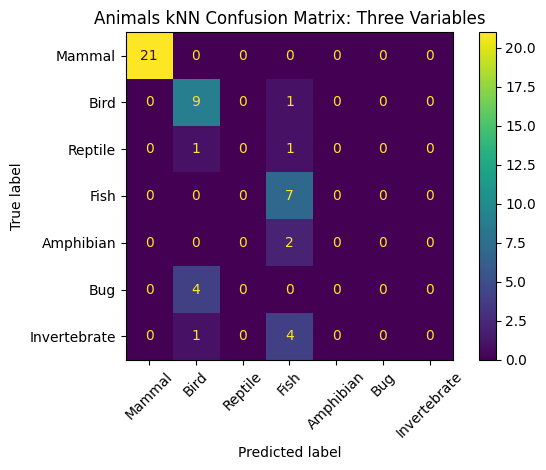

,animal,actual_class,predicted_class,Class 1,Class 2,Class 3,Class 4,Class 5,Class 6,Class 7
0,carp,4,4,0.0,0.0,0.0,0.5,0.0,0.0,0.5
1,elephant,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,goat,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,leopard,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,lark,2,2,0.0,1.0,0.0,0.0,0.0,0.0,0.0
5,frog,5,4,0.0,0.0,0.0,0.5,0.0,0.0,0.5
6,housefly,6,2,0.0,1.0,0.0,0.0,0.0,0.0,0.0
7,chub,4,4,0.0,0.0,0.0,0.5,0.0,0.0,0.5
8,lynx,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0
9,crow,2,2,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [19]:
small_features = ["milk", "aquatic", "airborne"]

X_small = animals[small_features]
y = animals["class"]

X_train_s, X_test_s, y_train_s, y_test_s, animal_train_s, animal_test_s = train_test_split(
    X_small, y, animals["animal"],
    test_size=0.50,
    random_state=42,
    stratify=y
)

q5_small_rows = []
q5_small_models = {}

for k in range(1, 26):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_s, y_train_s)
    pred = model.predict(X_test_s)

    q5_small_rows.append({
        "k": k,
        "accuracy": accuracy_score(y_test_s, pred),
        "predicted_classes": sorted(set(pred))
    })
    q5_small_models[k] = model

q5_small_results = pd.DataFrame(q5_small_rows)
display(q5_small_results.sort_values(["accuracy", "k"], ascending=[False, True]).head(10))

best_k_small = int(q5_small_results.sort_values(["accuracy", "k"], ascending=[False, True]).iloc[0]["k"])
best_model_small = q5_small_models[best_k_small]
pred_small = best_model_small.predict(X_test_s)

print(f"Best k using only milk, aquatic, and airborne: {best_k_small}")
print(f"Accuracy using only milk, aquatic, and airborne: {accuracy_score(y_test_s, pred_small):.3f}")
print(f"Classes predicted as final labels: {sorted(set(pred_small))}")
print(f"Classes represented in predict_proba columns: {list(best_model_small.classes_)}")

cm_small = confusion_matrix(y_test_s, pred_small, labels=list(range(1, 8)))
display(pd.DataFrame(cm_small, index=[f"Actual {i}" for i in range(1, 8)], columns=[f"Pred {i}" for i in range(1, 8)]))

ConfusionMatrixDisplay(cm_small, display_labels=[class_names[i] for i in range(1, 8)]).plot()
plt.title("Animals kNN Confusion Matrix: Three Variables")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

proba = pd.DataFrame(
    best_model_small.predict_proba(X_test_s),
    columns=[f"Class {c}" for c in best_model_small.classes_]
)

proba.insert(0, "animal", animal_test_s.values)
proba.insert(1, "actual_class", y_test_s.values)
proba.insert(2, "predicted_class", pred_small)

display(proba.head(12))

### Q5 Written Answer

The largest class is **class 1, mammals**, followed by **class 2, birds**. The smallest classes are **amphibians** and **reptiles**, so those are harder to learn from because there are fewer examples.

The variables that should be strongest for prediction are things like **milk**, **feathers**, **eggs**, **fins**, **aquatic**, **backbone**, **breathes**, and **legs**. These features line up closely with animal groups.

Using all variables, the best model in this split uses **k = 1** and has accuracy of about **98.0%**. The model only made one mistake: it predicted **seasnake** as a fish instead of a reptile. That mistake makes sense because seasnakes are aquatic and share some traits with fish in the dataset.

Using only `milk`, `aquatic`, and `airborne`, the best model uses **k = 2** and accuracy drops to about **72.5%**. The model only predicts a subset of the classes as final labels. In this split, it predicts only **classes 1, 2, and 4** as final labels, even though `predict_proba` still gives probability columns for all seven classes. This happens because those three variables are too limited. They separate mammals, birds, and fish fairly well, but they do not give enough detail to separate reptiles, amphibians, bugs, and invertebrates.

### AI References

AI (ChatGPT 5.2) was used to clean up code and formatting, as well as more advance sequences of code. All code was reviewed and submitted by me. 